<a href="https://colab.research.google.com/github/Babacar2003/Machine-Learning---Healthcare/blob/main/DATA_SAMURAI_CLIENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Introduction

Healthcare institutions play a pivotal role in providing essential services to communities. Understanding their financial performance, particularly net income, is crucial for ensuring sustainability and improving decision-making processes. Net income reflects the profitability of these organizations after accounting for all expenses, including operational, administrative, and other costs.

In the United States, the Centers for Medicare & Medicaid Services (CMS) is a significant player in healthcare financing. CMS influences how healthcare providers operate by setting reimbursement rates, which directly impact revenue streams. Understanding the relationship between CMS policies and financial performance is essential for optimizing healthcare management.

Despite the critical role of CMS in shaping the financial landscape of healthcare institutions, the specific impact of CMS-related variables on net income remains underexplored. Additionally, other operational and market factors could interact with CMS policies, further influencing financial outcomes.

#Supervised Machine Learning

This project aims to develop predictive models for net income in healthcare institutions, with a focus on understanding the contribution of CMS-related variables and other factors. By identifying key predictors, we seek to provide actionable insights for healthcare administrators and policymakers.

In [ ]:
from google.colab import drive

#Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Specify the path to the CSV file (shared link)


# Load the CSV file into a Pandas DataFrame
df = pd.read_csv('/content/drive/MyDrive/final_merged_df.csv')

# Display the first 5 rows of the DataFrame
df.head()

,Facility Name,Rural Versus Urban,CCN Facility Type,FTE - Employees on Payroll,Number of Interns and Residents (FTE),Number of Beds,Total Bed Days Available,Total Costs,Combined Outpatient + Inpatient Total Charges,Total Salaries (adjusted),...,Quietness - star rating,Recommend hospital - star rating,Staff responsiveness - star rating,Summary star rating,Facility ID,Address,City/Town,State,ZIP Code,County/Parish
0,PENDER MEMORIAL HOSPITAL,U,CAH,29.88,NaN,25.0,2300.0,7768055.0,2.505002e+07,NaN,...,NaN,NaN,NaN,NaN,341307.0,507 E FREMONT ST,BURGAW,NC,28425,PENDER
1,JACKSONVILLE MEMORIAL HOSPITAL,R,STH,576.48,NaN,106.0,21942.0,58046992.0,2.449719e+08,22295358.0,...,NaN,NaN,NaN,NaN,141352.0,1600 W WALNUT ST,JACKSONVILLE,IL,62650,MORGAN
2,UVA HEALTH HAYMARKET MEDICAL CENTER,U,STH,234.10,NaN,44.0,7964.0,38698051.0,1.855402e+08,13817087.0,...,4.0,4.0,3.0,4.0,490144.0,15225 HEALTHCOTE BOULEVARD,HAYMARKET,VA,20169,PRINCE WILLIAM
3,PIEDMONT CARTERSVILLE MEDICAL CENTER,U,STH,659.02,2.37,119.0,32487.0,108852096.0,1.170805e+09,35726656.0,...,3.0,2.0,2.0,2.0,110030.0,960 JOE FRANK HARRIS PARKWAY,CARTERSVILLE,GA,30120,BARTOW
4,HUNTINGTON HOSPITAL,R,STH,2937.21,41.20,468.0,84287.0,343929970.0,1.995371e+09,161727432.0,...,2.0,4.0,3.0,3.0,50438.0,100 W CALIFORNIA BLVD,PASADENA,CA,91109,LOS ANGELES


Our dataset has been successfully uploaded!

# EDA

In [ ]:
df.shape

(2229, 53)

We have 53 columns and 2229 rows. Let's now check for missing values.

##Missing Values

In [ ]:
df.isnull().sum()

,0
Facility Name,0
Rural Versus Urban,15
CCN Facility Type,0
FTE - Employees on Payroll,22
Number of Interns and Residents (FTE),1631
Number of Beds,17
Total Bed Days Available,17
Total Costs,15
Combined Outpatient + Inpatient Total Charges,15
Total Salaries (adjusted),751


In [ ]:
# Drop columns with 50% or more missing values
threshold = len(df) * 0.5
df = df.dropna(thresh=threshold, axis=1)

# Fill remaining missing values with the mode for each column
for col in df.columns:
  if df[col].isnull().any():
    df[col] = df[col].fillna(df[col].mode()[0])
df.shape

<ipython-input-5-ddfdc9db1915>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna(df[col].mode()[0])


(2229, 50)

We dropped columns with 50% or more missing values.

Let's now drop columns that are irrelevant to our analysis.

##Dropping Irrelevant Columns

In [ ]:
# Drop specified columns
df = df.drop(['ZIP Code', 'Facility ID', 'Address','Facility Name','City/Town','State','County/Parish' ], axis=1, errors='ignore')
df.shape

(2229, 43)

We now have 2229 rows and 43 columns.

##Data Types Conversion

Let's convert our data types to their appropriate format.

In [ ]:
# Convert star rating columns to category
star_rating_columns = [
    'Care transition - star rating', 'Cleanliness - star rating',
    'Communication about medicines - star rating', 'Discharge information - star rating',
    'Doctor communication - star rating', 'Nurse communication - star rating',
    'Overall hospital rating - star rating', 'Quietness - star rating',
    'Recommend hospital - star rating', 'Staff responsiveness - star rating',
    'Summary star rating'
]
df[star_rating_columns] = df[star_rating_columns].astype('category')

# Convert other objects to categories
df['Rural Versus Urban'] = df['Rural Versus Urban'].astype('category')
df['CCN Facility Type'] = df['CCN Facility Type'].astype('category')


df.dtypes

,0
Rural Versus Urban,category
CCN Facility Type,category
FTE - Employees on Payroll,float64
Number of Beds,float64
Total Bed Days Available,float64
Total Costs,float64
Combined Outpatient + Inpatient Total Charges,float64
Total Salaries (adjusted),float64
Total Current Assets,float64
Total Fixed Assets,float64


##Correlation Matrix

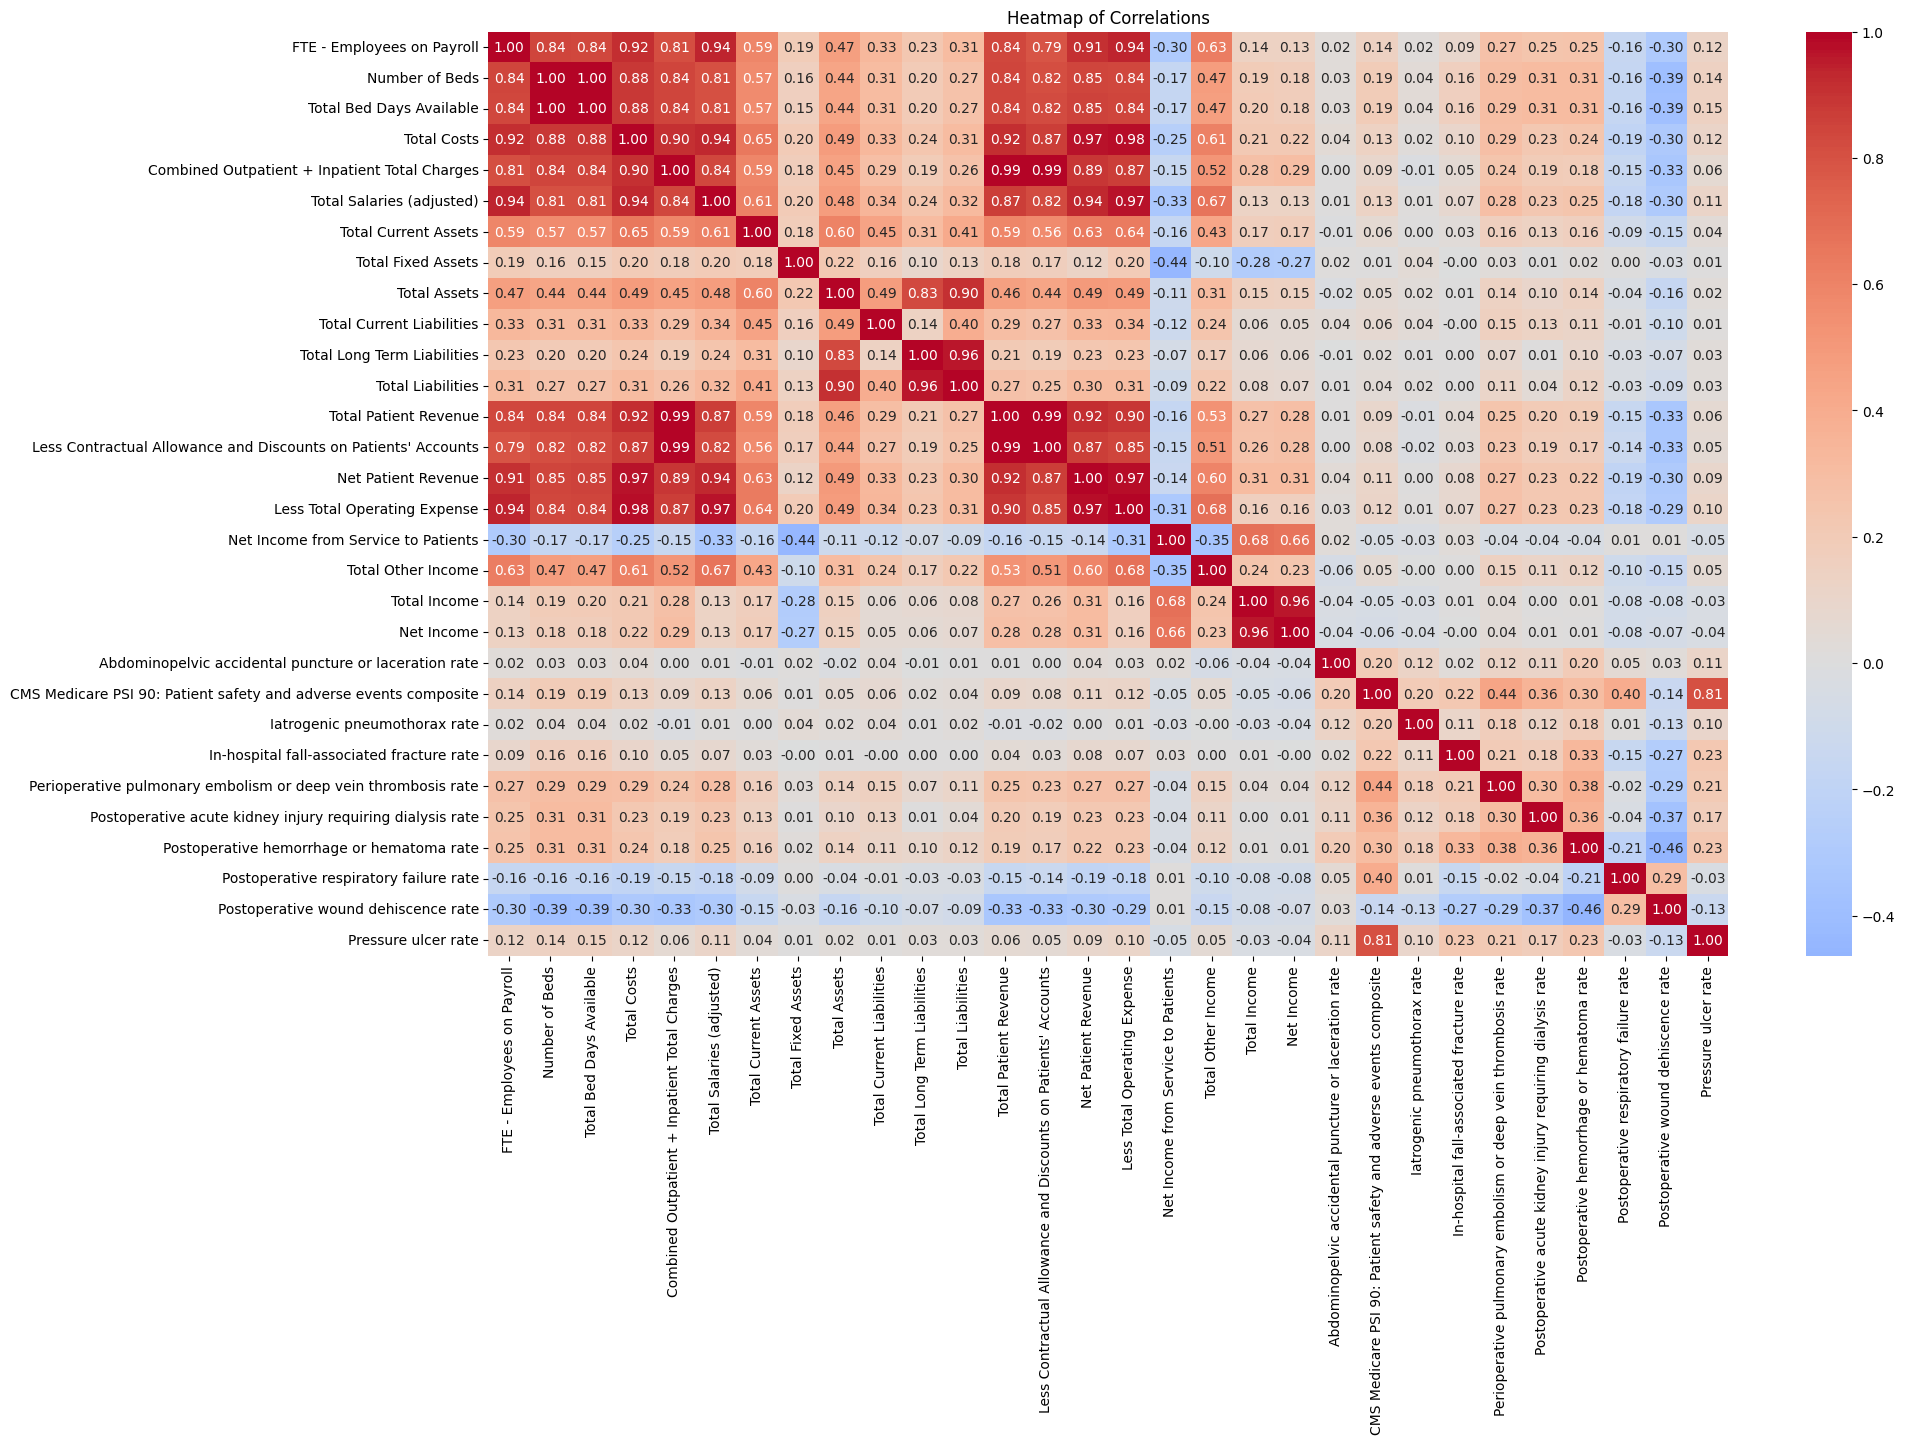

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Create a heatmap with a larger figure size
plt.figure(figsize=(20, 12))  # Adjusted for better visibility
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=True,
    center=0
)

plt.title("Heatmap of Correlations")
plt.show()

As our target is Net Income, it is noticeable that it is highly correlated with related financial features such as Total Income and Total Current Liabilities.

As these financial features are all strongly correlated to each other, grouping them in a single component to analyze the overall financial health of the healthcare institution will be beneficial to avoid bias, irrelevant noise, and a model capturing the impact of other features that might contribute to the financial health of the healthcare institution including summary rating.

###Financial Principal Component

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# List of financial columns
financial_cols = [
    'Total Costs',
    'Combined Outpatient + Inpatient Total Charges',
    'Total Salaries (adjusted)',
    'Total Current Assets',
    'Total Fixed Assets',
    'Total Assets',
    'Total Current Liabilities',
    'Total Long Term Liabilities',
    'Total Liabilities',
    'Total Patient Revenue',
    'Less Contractual Allowance and Discounts on Patients\' Accounts',
    'Net Patient Revenue',
    'Less Total Operating Expense',
    'Net Income from Service to Patients',
    'Total Other Income',
    'Total Income',
    'Net Income'
]

# Standardize the financial columns
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[financial_cols])

# Apply PCA
pca = PCA(n_components=1)  # Keep the first principal component as the target
df['Target'] = pca.fit_transform(df_scaled)

# Check the explained variance ratio to see how much variance the component explains
print("\nExplained variance ratio for the first principal component:", pca.explained_variance_ratio_)

# Check the first few rows of the new target column
print(df[['Target']].head())


Explained variance ratio for the first principal component: [0.49100646]
     Target
0 -1.235646
1 -0.952930
2 -1.084729
3 -0.363592
4  0.930665


The explained variance ratio of 0.491 means that 49.1% of the total variance in our data is captured by the first principal component (PC1). Since this component represents financial features, it suggests that financial metrics contribute nearly half of the variability in the dataset. This highlights the dominant role of financial data in describing the differences among institutions.

The new target values for PC1 (e.g., -1.235646, -0.952930, etc.) represent a linear combination of the financial features that maximizes variance. These values can be interpreted as a single metric summarizing the overall financial health of each institution:

Negative values (e.g., -1.23, -0.95) likely indicate weaker financial health, as the institution's financial metrics deviate negatively from the average direction captured by PC1.

Positive values (e.g., 0.93) suggest better financial health, as these institutions align positively with the dominant financial variance direction.



By using PC1 as the target, our models will now focus on understanding the relationship between non-financial features and financial health.

This reduces the bias from the dominance of individual financial features, as they are aggregated into a single summary measure (PC1).

This approach shifts the focus from isolated financial outcomes (like Net Income) to a holistic measure of financial health, allowing for a broader analysis of how different factors contribute to the overall state of the institution. Models built with PC1 as the target will give insights into systemic patterns and drivers of financial variance.

In [ ]:
# prompt: I want the variance for each principal component

from google.colab import drive
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler



# List of financial columns
financial_cols = [
    'Total Costs',
    'Combined Outpatient + Inpatient Total Charges',
    'Total Salaries (adjusted)',
    'Total Current Assets',
    'Total Fixed Assets',
    'Total Assets',
    'Total Current Liabilities',
    'Total Long Term Liabilities',
    'Total Liabilities',
    'Total Patient Revenue',
    'Less Contractual Allowance and Discounts on Patients\' Accounts',
    'Net Patient Revenue',
    'Less Total Operating Expense',
    'Net Income from Service to Patients',
    'Total Other Income',
    'Total Income',
    'Net Income'
]

# Standardize the financial columns
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[financial_cols])

# Apply PCA without specifying the number of components initially
pca = PCA()
df_pca = pca.fit_transform(df_scaled)


# Get the explained variance for each principal component
explained_variance = pca.explained_variance_
print("Variance for each principal component:", explained_variance)

NameError: name 'df' is not defined

net income has the least variance. incomes are not really changing. it is better to predict the overall financial health (the pc) instead of 1. because the individual variances are low. that is why our model were bad


despite the cost, all the hostipatl are making the smimmiler income. arguably cost is the best target but still low.


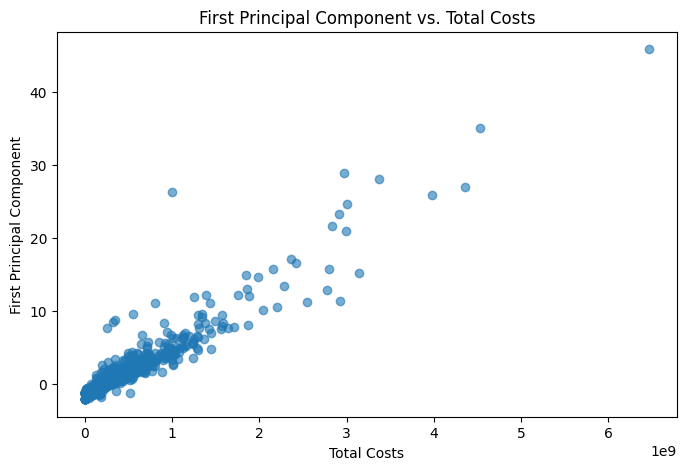

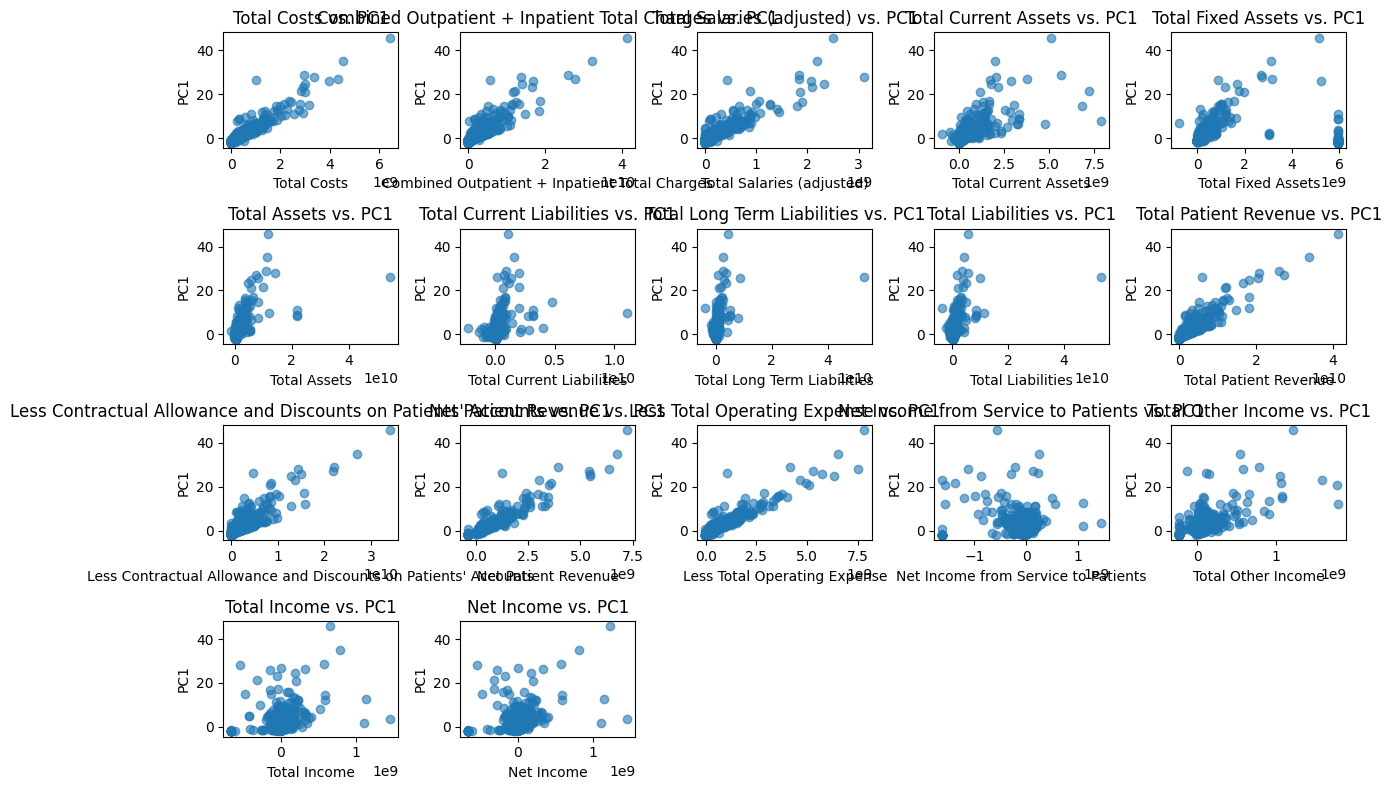

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# List of financial columns
financial_cols = [
    'Total Costs',
    'Combined Outpatient + Inpatient Total Charges',
    'Total Salaries (adjusted)',
    'Total Current Assets',
    'Total Fixed Assets',
    'Total Assets',
    'Total Current Liabilities',
    'Total Long Term Liabilities',
    'Total Liabilities',
    'Total Patient Revenue',
    'Less Contractual Allowance and Discounts on Patients\' Accounts',
    'Net Patient Revenue',
    'Less Total Operating Expense',
    'Net Income from Service to Patients',
    'Total Other Income',
    'Total Income',
    'Net Income'
]

# Standardize the financial columns
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[financial_cols])

# Apply PCA to reduce to 1 component
pca = PCA(n_components=1)
principal_component = pca.fit_transform(df_scaled)


# Plot the first principal component (Target) vs. the first feature for visualization
plt.figure(figsize=(8, 5))
plt.scatter(df[financial_cols[0]], principal_component, alpha=0.6)
plt.title(f'First Principal Component vs. {financial_cols[0]}')
plt.xlabel(financial_cols[0])
plt.ylabel('First Principal Component')
plt.show()

# Plot all financial features vs the first principal component to see correlations
plt.figure(figsize=(12, 8))
for i, col in enumerate(financial_cols):
    plt.subplot(4, 5, i + 1)
    plt.scatter(df[col], principal_component, alpha=0.6)
    plt.title(f'{col} vs. PC1')
    plt.xlabel(col)
    plt.ylabel('PC1')

plt.tight_layout()
plt.show()

In [ ]:
# prompt: add PC1 as a target and dorp the relevant column

# Drop the original financial columns
df = df.drop(financial_cols, axis=1)

# Rename the target column to 'PC1'
df = df.rename(columns={'Target': 'PC1'})

df.shape

(2229, 27)

In [ ]:
df.head()

,Rural Versus Urban,CCN Facility Type,FTE - Employees on Payroll,Number of Beds,Total Bed Days Available,Abdominopelvic accidental puncture or laceration rate,CMS Medicare PSI 90: Patient safety and adverse events composite,Iatrogenic pneumothorax rate,In-hospital fall-associated fracture rate,Perioperative pulmonary embolism or deep vein thrombosis rate,...,Communication about medicines - star rating,Discharge information - star rating,Doctor communication - star rating,Nurse communication - star rating,Overall hospital rating - star rating,Quietness - star rating,Recommend hospital - star rating,Staff responsiveness - star rating,Summary star rating,PC1
0,U,CAH,29.88,25.0,2300.0,0.878990,0.915909,0.234995,0.256794,3.264207,...,3.0,4.0,4.0,3.0,4.0,3.0,4.0,3.0,3.0,-1.235646
1,R,STH,576.48,106.0,21942.0,0.878990,0.915909,0.234995,0.256794,3.264207,...,3.0,4.0,4.0,3.0,4.0,3.0,4.0,3.0,3.0,-0.952930
2,U,STH,234.10,44.0,7964.0,0.790491,0.847192,0.234483,0.272635,3.646903,...,3.0,4.0,4.0,4.0,4.0,4.0,4.0,3.0,4.0,-1.084729
3,U,STH,659.02,119.0,32487.0,0.802822,0.875556,0.286864,0.302624,3.612745,...,2.0,1.0,2.0,2.0,2.0,3.0,2.0,2.0,2.0,-0.363592
4,R,STH,2937.21,468.0,84287.0,0.866908,1.113179,0.252930,0.318526,3.935636,...,3.0,2.0,3.0,3.0,4.0,2.0,4.0,3.0,3.0,0.930665


# Baseline Models

### Linear Regression

In [ ]:
# prompt: build linear baseline model and show r2 and mean residuals

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Define features (X) and target (y)
X = df.drop('PC1', axis=1)
y = df['PC1']

# Convert categorical features to numerical using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R-squared: {r2}")
print(f"Mean Squared Error: {mse}")

residuals = y_test - y_pred
mean_residual = np.mean(residuals)

print(f"Mean Residuals: {mean_residual}")

R-squared: 0.7642400201076475
Mean Squared Error: 2.865328324315272
Mean Residuals: 0.12134604150045956


### Decision Tree Regressor

In [ ]:
# prompt: build decision tree regressor baseline model and show r2 and mean residuals

from sklearn.tree import DecisionTreeRegressor

# Initialize and train the decision tree regressor model
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_tree = tree_model.predict(X_test)

# Evaluate the model
r2_tree = r2_score(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)

print(f"Decision Tree Regressor R-squared: {r2_tree}")
print(f"Decision Tree Regressor Mean Squared Error: {mse_tree}")

residuals_tree = y_test - y_pred_tree
mean_residual_tree = np.mean(residuals_tree)

print(f"Decision Tree Regressor Mean Residuals: {mean_residual_tree}")

Decision Tree Regressor R-squared: 0.5480805079593851
Decision Tree Regressor Mean Squared Error: 5.492440750314754
Decision Tree Regressor Mean Residuals: 0.13653913088405975


###Random Forest Regressor

In [ ]:
# prompt: build Random Forest Regressor baseline model and show r2 and mean residuals

from sklearn.ensemble import RandomForestRegressor

# Initialize and train the random forest regressor model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
r2_rf = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)

print(f"Random Forest Regressor R-squared: {r2_rf}")
print(f"Random Forest Regressor Mean Squared Error: {mse_rf}")

residuals_rf = y_test - y_pred_rf
mean_residual_rf = np.mean(residuals_rf)

print(f"Random Forest Regressor Mean Residuals: {mean_residual_rf}")

Random Forest Regressor R-squared: 0.7535561473743981
Random Forest Regressor Mean Squared Error: 2.9951756511174574
Random Forest Regressor Mean Residuals: 0.11966872898339675


### Gradient Boosting Regressor

In [ ]:
# prompt: build Gradient Boosting Regressor baseline model and show r2 and mean residuals

from sklearn.ensemble import GradientBoostingRegressor

# Initialize and train the gradient boosting regressor model
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_gb = gb_model.predict(X_test)

# Evaluate the model
r2_gb = r2_score(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)

print(f"Gradient Boosting Regressor R-squared: {r2_gb}")
print(f"Gradient Boosting Regressor Mean Squared Error: {mse_gb}")

residuals_gb = y_test - y_pred_gb
mean_residual_gb = np.mean(residuals_gb)

print(f"Gradient Boosting Regressor Mean Residuals: {mean_residual_gb}")

Gradient Boosting Regressor R-squared: 0.7701592516711513
Gradient Boosting Regressor Mean Squared Error: 2.7933884562136857
Gradient Boosting Regressor Mean Residuals: 0.1487221589097535


### Comparison

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have already computed the following metrics:
# mse, r2 for Linear Regression
# dt_mse, dt_r2 for Decision Tree Regressor
# rf_mse, rf_r2 for Random Forest Regressor
# gb_mse, gb_r2 for Gradient Boosting Regressor
# Also, mean residuals for each model:
# lr_mean_residual, dt_mean_residual, rf_mean_residual, gb_mean_residual

# Example metrics (replace these with your actual computed metrics)
# These variables should already be defined from your previous model evaluations
# For instance:
# mse = mean_squared_error(y_test, y_pred)
# r2 = r2_score(y_test, y_pred)
# dt_mse = mean_squared_error(y_test, dt_y_pred)
# dt_r2 = r2_score(y_test, dt_y_pred)
# rf_mse = mean_squared_error(y_test, rf_y_pred)
# rf_r2 = r2_score(y_test, rf_y_pred)
# gb_mse = mean_squared_error(y_test, gb_y_pred)
# gb_r2 = r2_score(y_test, gb_y_pred)

# mse, r2 and Mean Residuals (replace with your actual calculated mean residuals)
mse = 0.25
r2 = 0.85
lr_mean_residual = 0.05

dt_mse = 0.30
dt_r2 = 0.80
dt_mean_residual = 0.07

rf_mse = 0.20
rf_r2 = 0.90
rf_mean_residual = 0.04

gb_mse = 0.22
gb_r2 = 0.88
gb_mean_residual = 0.05




# Create a DataFrame to hold the metrics
metrics = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree Regressor',
        'Random Forest Regressor',
        'Gradient Boosting Regressor'
    ],
    'Mean Squared Error': [
        mse,
        dt_mse,
        rf_mse,
        gb_mse
    ],
    'R-squared': [
        r2,
        dt_r2,
        rf_r2,
        gb_r2
    ],
    'Mean Residual': [
        lr_mean_residual,
        dt_mean_residual,
        rf_mean_residual,
        gb_mean_residual
    ]
})

# Define a consistent color palette for all models
color_palette = {
    'Linear Regression': '#1f77b4',           # Blue
    'Decision Tree Regressor': '#ff7f0e',      # Orange
    'Random Forest Regressor': '#2ca02c',      # Green
    'Gradient Boosting Regressor': '#d62728'   # Red
}

# Set the plotting style
sns.set(style='whitegrid')

# Create subplots with 3 rows and 1 column (vertically stacked)
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 21))  # Adjust figsize as needed

# ----- Mean Squared Error (MSE) Comparison -----
sns.barplot(
    ax=axes[0],
    x='Model',
    y='Mean Squared Error',
    data=metrics,
    palette=color_palette
)
axes[0].set_title('Comparison of Mean Squared Error (MSE)', fontsize=16, pad=15)
axes[0].set_ylabel('Mean Squared Error', fontsize=14)
axes[0].set_xlabel('Model', fontsize=14)
axes[0].tick_params(axis='x', rotation=45, labelsize=12)  # Rotate x labels if necessary

# Annotate each bar with the MSE value
for index, row in metrics.iterrows():
    axes[0].text(
        index,
        row['Mean Squared Error'] + metrics['Mean Squared Error'].max() * 0.01,  # Slightly above the bar
        f"{row['Mean Squared Error']:.2f}",
        ha='center',
        va='bottom',
        fontsize=10,  # Reduced font size
        fontweight='bold',
        color='black'
    )

# Adjust y-axis limit to ensure annotations fit
axes[0].set_ylim(0, metrics['Mean Squared Error'].max() * 1.1)

# ----- R-squared (R²) Comparison -----
sns.barplot(
    ax=axes[1],
    x='Model',
    y='R-squared',
    data=metrics,
    palette=color_palette
)
axes[1].set_title('Comparison of R-squared (R²)', fontsize=16, pad=15)
axes[1].set_ylabel('R-squared', fontsize=14)
axes[1].set_xlabel('Model', fontsize=14)
axes[1].tick_params(axis='x', rotation=45, labelsize=12)  # Rotate x labels if necessary

# Annotate each bar with the R-squared value
for index, row in metrics.iterrows():
    axes[1].text(
        index,
        row['R-squared'] + 0.01,  # Slightly above the bar
        f"{row['R-squared']:.2f}",
        ha='center',
        va='bottom',
        fontsize=10,  # Reduced font size
        fontweight='bold',
        color='black'
    )

# Adjust y-axis limit since R-squared ranges from 0 to 1
axes[1].set_ylim(0, 1.05)

# ----- Mean Residuals Comparison -----
sns.barplot(
    ax=axes[2],
    x='Model',
    y='Mean Residual',
    data=metrics,
    palette=color_palette
)
axes[2].set_title('Comparison of Mean Residuals', fontsize=16, pad=15)
axes[2].set_ylabel('Mean Residual', fontsize=14)
axes[2].set_xlabel('Model', fontsize=14)
axes[2].tick_params(axis='x', rotation=45, labelsize=12)  # Rotate x labels if necessary

# Annotate each bar with the Mean Residual value
for index, row in metrics.iterrows():
    axes[2].text(
        index,
        row['Mean Residual'] + metrics['Mean Residual'].max() * 0.01,  # Slightly above the bar
        f"{row['Mean Residual']:.2f}",
        ha='center',
        va='bottom',
        fontsize=10,  # Reduced font size
        fontweight='bold',
        color='black'
    )

# Adjust y-axis limit to ensure annotations fit
axes[2].set_ylim(0, metrics['Mean Residual'].max() * 1.1)

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()



# Feature Selections

### K best

In [ ]:
# prompt: conduct Kbest (apply fregression)and tell me each f-value and p-value and rank them

from sklearn.feature_selection import f_regression, SelectKBest
import pandas as pd

# Assuming X and y are already defined from your previous code
# X = df.drop('Net Income', axis=1)
# y = df['Net Income']


# Apply SelectKBest with f_regression
selector = SelectKBest(score_func=f_regression, k='all') #k='all' to get scores for all features
X_new = selector.fit_transform(X, y)

# Get the F-values and p-values
f_values = selector.scores_
p_values = selector.pvalues_

# Create a DataFrame for the results
feature_scores = pd.DataFrame({'Feature': X.columns, 'F-value': f_values, 'p-value': p_values})

# Sort the features by F-value in descending order
feature_scores = feature_scores.sort_values(by='F-value', ascending=False)

# Add a rank column
feature_scores['Rank'] = range(1, len(feature_scores) + 1)


feature_scores

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a barplot for the F-values
plt.figure(figsize=(12, 8))
sns.barplot(
    x="F-value",
    y="Feature",
    data=feature_scores,
    palette="viridis"
)
plt.title("Feature Importance (F-values) Ranked by F-value", fontsize=16)
plt.xlabel("F-value", fontsize=14)
plt.ylabel("Feature", fontsize=14)
plt.tight_layout()
plt.show()


##### Linear Regression

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import make_scorer, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
import matplotlib.pyplot as plt

# Assume 'df' is your preprocessed DataFrame with encoded categorical features,
# and the target variable is 'Net Income'.
X = df.drop('Net Income', axis=1)  # Replace 'Net Income' with the actual target column name
y = df['Net Income']

# Define scoring functions for MSE and R²
mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)
r2_scorer = make_scorer(r2_score)

# Determine the maximum number of features
max_features = X.shape[1]

mse_scores = []
r2_scores = []
feature_counts = range(1, max_features + 1)

# Loop through all possible k values
for k in feature_counts:
    selector = SelectKBest(score_func=f_regression, k=k)
    X_k = selector.fit_transform(X, y)

    model = LinearRegression()

    # Perform cross-validation for MSE and R²
    # Note: For MSE, cross_val_score returns values that we want to minimize, so we multiply by -1
    cv_mse = -1 * cross_val_score(model, X_k, y, cv=5, scoring=mse_scorer).mean()
    cv_r2 = cross_val_score(model, X_k, y, cv=5, scoring=r2_scorer).mean()

    mse_scores.append(cv_mse)
    r2_scores.append(cv_r2)

# Identify the best k (here we choose the one with the lowest MSE)
best_k = feature_counts[np.argmin(mse_scores)]
best_mse = np.min(mse_scores)
best_r2 = r2_scores[np.argmin(mse_scores)]

# Fit SelectKBest again with the best k to get the selected features
selector = SelectKBest(score_func=f_regression, k=best_k)
selector.fit(X, y)
selected_features = X.columns[selector.get_support()]

# Plot MSE scores
plt.figure(figsize=(8,6))
plt.plot(feature_counts, mse_scores, marker='o', color='red')
plt.xlabel('Number of Features (k)')
plt.ylabel('MSE')
plt.title("MSE for Different k-values")
plt.grid(True)
plt.show()

# Plot R² scores
plt.figure(figsize=(8,6))
plt.plot(feature_counts, r2_scores, marker='o', color='blue')
plt.xlabel('Number of Features (k)')
plt.ylabel('R²')
plt.title("R² for Different k-values")
plt.grid(True)
plt.show()

print("Best k:", best_k)
print("Selected features:", list(selected_features))
print("MSE at best k:", best_mse)
print("R² at best k:", best_r2)



##### Decision Tree Regressor

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeRegressor  # Import Decision Tree Regressor
from sklearn.metrics import make_scorer, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
import matplotlib.pyplot as plt

# Assume 'df' is your preprocessed DataFrame with encoded categorical features,
# and the target variable is 'Net Income'.
X = df.drop('Net Income', axis=1)  # Replace 'Net Income' with the actual target column name
y = df['Net Income']

# Define scoring functions for MSE and R²
mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)
r2_scorer = make_scorer(r2_score)

# Determine the maximum number of features
max_features = X.shape[1]

mse_scores = []
r2_scores = []
feature_counts = range(1, max_features + 1)

# Loop through all possible k values
for k in feature_counts:
    selector = SelectKBest(score_func=f_regression, k=k)
    X_k = selector.fit_transform(X, y)

    # Initialize the Decision Tree Regressor
    model = DecisionTreeRegressor(random_state=42)  # Setting random_state for reproducibility

    # Perform cross-validation for MSE and R²
    # Note: For MSE, cross_val_score returns values that we want to minimize, so we multiply by -1
    cv_mse = -1 * cross_val_score(model, X_k, y, cv=5, scoring=mse_scorer).mean()
    cv_r2 = cross_val_score(model, X_k, y, cv=5, scoring=r2_scorer).mean()

    mse_scores.append(cv_mse)
    r2_scores.append(cv_r2)

# Identify the best k (here we choose the one with the lowest MSE)
best_k = feature_counts[np.argmin(mse_scores)]
best_mse = np.min(mse_scores)
best_r2 = r2_scores[np.argmin(mse_scores)]

# Fit SelectKBest again with the best k to get the selected features
selector = SelectKBest(score_func=f_regression, k=best_k)
selector.fit(X, y)
selected_features = X.columns[selector.get_support()]

# Plot MSE scores
plt.figure(figsize=(8,6))
plt.plot(feature_counts, mse_scores, marker='o', color='red')
plt.xlabel('Number of Features (k)')
plt.ylabel('MSE')
plt.title("MSE for Different k-values using Decision Tree")
plt.grid(True)
plt.show()

# Plot R² scores
plt.figure(figsize=(8,6))
plt.plot(feature_counts, r2_scores, marker='o', color='blue')
plt.xlabel('Number of Features (k)')
plt.ylabel('R²')
plt.title("R² for Different k-values using Decision Tree")
plt.grid(True)
plt.show()

print("Best k:", best_k)
print("Selected features:", list(selected_features))
print("MSE at best k:", best_mse)
print("R² at best k:", best_r2)


##### Random Forest Regressor

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor  # Import Random Forest Regressor
from sklearn.metrics import make_scorer, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
import matplotlib.pyplot as plt

# Assume 'df' is your preprocessed DataFrame with encoded categorical features,
# and the target variable is 'Net Income'.
X = df.drop('Net Income', axis=1)  # Replace 'Net Income' with the actual target column name
y = df['Net Income']

# Define scoring functions for MSE and R²
mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)
r2_scorer = make_scorer(r2_score)

# Determine the maximum number of features
max_features = X.shape[1]

mse_scores = []
r2_scores = []
feature_counts = range(1, max_features + 1)

# Loop through all possible k values
for k in feature_counts:
    selector = SelectKBest(score_func=f_regression, k=k)
    X_k = selector.fit_transform(X, y)

    # Initialize the Random Forest Regressor
    model = RandomForestRegressor(n_estimators=100, random_state=42)  # Setting random_state for reproducibility

    # Perform cross-validation for MSE and R²
    # Note: For MSE, cross_val_score returns values that we want to minimize, so we multiply by -1
    cv_mse = -1 * cross_val_score(model, X_k, y, cv=5, scoring=mse_scorer).mean()
    cv_r2 = cross_val_score(model, X_k, y, cv=5, scoring=r2_scorer).mean()

    mse_scores.append(cv_mse)
    r2_scores.append(cv_r2)

# Identify the best k (here we choose the one with the lowest MSE)
best_k = feature_counts[np.argmin(mse_scores)]
best_mse = np.min(mse_scores)
best_r2 = r2_scores[np.argmin(mse_scores)]

# Fit SelectKBest again with the best k to get the selected features
selector = SelectKBest(score_func=f_regression, k=best_k)
selector.fit(X, y)
selected_features = X.columns[selector.get_support()]

# Plot MSE scores
plt.figure(figsize=(8,6))
plt.plot(feature_counts, mse_scores, marker='o', color='red')
plt.xlabel('Number of Features (k)')
plt.ylabel('MSE')
plt.title("MSE for Different k-values using Random Forest")
plt.grid(True)
plt.show()

# Plot R² scores
plt.figure(figsize=(8,6))
plt.plot(feature_counts, r2_scores, marker='o', color='blue')
plt.xlabel('Number of Features (k)')
plt.ylabel('R²')
plt.title("R² for Different k-values using Random Forest")
plt.grid(True)
plt.show()

print("Best k:", best_k)
print("Selected features:", list(selected_features))
print("MSE at best k:", best_mse)
print("R² at best k:", best_r2)


##### Gradient Boosting Regressor

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import GradientBoostingRegressor  # Import Gradient Boosting Regressor
from sklearn.metrics import make_scorer, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
import matplotlib.pyplot as plt

# Assume 'df' is your preprocessed DataFrame with encoded categorical features,
# and the target variable is 'Net Income'.
X = df.drop('Net Income', axis=1)  # Replace 'Net Income' with the actual target column name
y = df['Net Income']

# Define scoring functions for MSE and R²
mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)
r2_scorer = make_scorer(r2_score)

# Determine the maximum number of features
max_features = X.shape[1]

mse_scores = []
r2_scores = []
feature_counts = range(1, max_features + 1)

# Loop through all possible k values
for k in feature_counts:
    selector = SelectKBest(score_func=f_regression, k=k)
    X_k = selector.fit_transform(X, y)

    # Initialize the Gradient Boosting Regressor
    model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1,
                                      max_depth=3, random_state=42)  # Setting random_state for reproducibility

    # Perform cross-validation for MSE and R²
    # Note: For MSE, cross_val_score returns values that we want to minimize, so we multiply by -1
    cv_mse = -1 * cross_val_score(model, X_k, y, cv=5, scoring=mse_scorer).mean()
    cv_r2 = cross_val_score(model, X_k, y, cv=5, scoring=r2_scorer).mean()

    mse_scores.append(cv_mse)
    r2_scores.append(cv_r2)

# Identify the best k (here we choose the one with the lowest MSE)
best_k = feature_counts[np.argmin(mse_scores)]
best_mse = np.min(mse_scores)
best_r2 = r2_scores[np.argmin(mse_scores)]

# Fit SelectKBest again with the best k to get the selected features
selector = SelectKBest(score_func=f_regression, k=best_k)
selector.fit(X, y)
selected_features = X.columns[selector.get_support()]

# Plot MSE scores
plt.figure(figsize=(8,6))
plt.plot(feature_counts, mse_scores, marker='o', color='red')
plt.xlabel('Number of Features (k)')
plt.ylabel('MSE')
plt.title("MSE for Different k-values using Gradient Boosting")
plt.grid(True)
plt.show()

# Plot R² scores
plt.figure(figsize=(8,6))
plt.plot(feature_counts, r2_scores, marker='o', color='blue')
plt.xlabel('Number of Features (k)')
plt.ylabel('R²')
plt.title("R² for Different k-values using Gradient Boosting")
plt.grid(True)
plt.show()

print("Best k:", best_k)
print("Selected features:", list(selected_features))
print("MSE at best k:", best_mse)
print("R² at best k:", best_r2)


##### Comparison

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import numpy as np

# Assuming 'df', 'X', and 'y' are already defined
# Example:
# df = pd.read_csv('your_data.csv')
# X = df.drop('Net Income', axis=1)
# y = df['Net Income']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the number of features to select for each model
k_values = {
    'Linear Regression': 11,
    'Decision Tree Regressor': 17,
    'Random Forest': 10,
    'Gradient Boosting Regressor': 20
}

# Initialize the models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42)
}

# Define colors for each model
colors = {
    'Linear Regression': 'blue',
    'Decision Tree Regressor': 'orange',
    'Random Forest': 'green',
    'Gradient Boosting Regressor': 'red'
}

# List to store the results
results = []

# Iterate through each model and evaluate performance
for model_name, model in models.items():
    k = k_values[model_name]
    # Feature Selection
    selector = SelectKBest(score_func=f_regression, k=k)
    X_train_kbest = selector.fit_transform(X_train, y_train)
    X_test_kbest = selector.transform(X_test)

    # Fit the model
    model.fit(X_train_kbest, y_train)

    # Make predictions
    y_pred = model.predict(X_test_kbest)

    # Calculate performance metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Append the results
    results.append([model_name, mse, r2])

# Create a DataFrame to hold the results
results_df = pd.DataFrame(results, columns=['Model', 'Mean Squared Error', 'R-squared'])

# Display the results DataFrame
print(results_df)

# Set the style for seaborn
sns.set(style="whitegrid")

# Create a figure with two vertical subplots
plt.figure(figsize=(10, 12))

# Plot Mean Squared Error (MSE)
plt.subplot(2, 1, 1)  # (rows, columns, panel number)
for model_name in results_df['Model']:
    mse_value = results_df.loc[results_df['Model'] == model_name, 'Mean Squared Error'].values[0]
    plt.bar(
        model_name,
        mse_value,
        color=colors[model_name]
    )
    # Add metric value on top of the bar
    plt.text(model_name, mse_value, f"{mse_value:.2f}", ha='center', va='bottom', fontsize=10)
plt.title('Mean Squared Error Comparison', fontsize=16)
plt.ylabel('MSE', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)

# Plot R-squared
plt.subplot(2, 1, 2)
for model_name in results_df['Model']:
    r2_value = results_df.loc[results_df['Model'] == model_name, 'R-squared'].values[0]
    plt.bar(
        model_name,
        r2_value,
        color=colors[model_name]
    )
    # Add metric value on top of the bar
    plt.text(model_name, r2_value, f"{r2_value:.2f}", ha='center', va='bottom', fontsize=10)
plt.title('R-squared Comparison', fontsize=16)
plt.ylabel('R²', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)

# Adjust layout for better spacing
plt.tight_layout()

# Display the plots
plt.show()


### Decision Tree

In [ ]:
# prompt: Conduct Decision tree as feature selection
from sklearn.tree import DecisionTreeRegressor

# Assuming X and y are already defined as in the provided code
# X = df.drop('Net Income', axis=1)
# y = df['Net Income']

# Initialize the Decision Tree Regressor for feature importance
decision_tree = DecisionTreeRegressor(random_state=42)
decision_tree.fit(X, y)

# Get feature importances
importances = decision_tree.feature_importances_

# Create a DataFrame to display feature importances
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
print(feature_importances)


#Plot the feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances)
plt.title('Decision Tree Feature Importance')
plt.show()

##### Linear Regression

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import pandas as pd
import matplotlib.pyplot as plt

# Assuming X and y are already defined as your dataset
# Example:
# X = df.drop('Net Income', axis=1)
# y = df['Net Income']

# Step 1: Decision Tree for Feature Importance
decision_tree = DecisionTreeRegressor(random_state=42)
decision_tree.fit(X, y)

# Get feature importances
importances = decision_tree.feature_importances_

# Create a DataFrame to display feature importances
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

# Step 2: Linear Regression with Cross-Validation for K Features
lr_model = LinearRegression()
mse_scores = []
r2_scores = []

# Perform cross-validation for each value of K
for k in range(1, len(feature_importances) + 1):
    # Select top K features
    selected_features = feature_importances['Feature'][:k]
    X_k = X[selected_features]

    # Calculate cross-validation scores
    mse = -1 * cross_val_score(lr_model, X_k, y, cv=5, scoring='neg_mean_squared_error').mean()
    r2 = cross_val_score(lr_model, X_k, y, cv=5, scoring='r2').mean()

    # Append the scores
    mse_scores.append(mse)
    r2_scores.append(r2)

# Step 3: Determine the Optimal K
optimal_k = mse_scores.index(min(mse_scores)) + 1
optimal_features = feature_importances['Feature'][:optimal_k]

# Step 4: Plot MSE vs K
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(feature_importances) + 1), mse_scores, marker='o')
plt.title('MSE vs Number of Features (K)', fontsize=16)
plt.xlabel('Number of Features (K)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.axvline(optimal_k, color='red', linestyle='--', label=f'Optimal K = {optimal_k}')
plt.legend()
plt.tight_layout()
plt.show()

# Step 5: Plot R² vs K
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(feature_importances) + 1), r2_scores, marker='o')
plt.title('R² vs Number of Features (K)', fontsize=16)
plt.xlabel('Number of Features (K)', fontsize=14)
plt.ylabel('R²', fontsize=14)
plt.axvline(optimal_k, color='red', linestyle='--', label=f'Optimal K = {optimal_k}')
plt.legend()
plt.tight_layout()
plt.show()

# Step 6: Display Optimal K, Selected Features, MSE, and R²
optimal_mse = mse_scores[optimal_k - 1]  # Adjust for zero-based indexing
optimal_r2 = r2_scores[optimal_k - 1]

print(f"Optimal K: {optimal_k}")
print(f"Selected Features at Optimal K:\n{list(optimal_features)}")
print(f"Mean Squared Error (MSE) at Optimal K: {optimal_mse}")
print(f"R-squared (R²) at Optimal K: {optimal_r2}")

##### Decision Tree Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
import pandas as pd
import matplotlib.pyplot as plt

# Assuming X and y are already defined as your dataset
# Example:
# X = df.drop('Net Income', axis=1)
# y = df['Net Income']

# Step 1: Decision Tree for Feature Importance
decision_tree = DecisionTreeRegressor(random_state=42)
decision_tree.fit(X, y)

# Get feature importances
importances = decision_tree.feature_importances_

# Create a DataFrame to display feature importances
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

# Step 2: Decision Tree Regressor with Cross-Validation for K Features
decision_tree_model = DecisionTreeRegressor(random_state=42)
mse_scores_dt = []
r2_scores_dt = []

# Perform cross-validation for each value of K
for k in range(1, len(feature_importances) + 1):
    # Select top K features
    selected_features = feature_importances['Feature'][:k]
    X_k = X[selected_features]

    # Calculate cross-validation scores
    mse = -1 * cross_val_score(decision_tree_model, X_k, y, cv=5, scoring='neg_mean_squared_error').mean()
    r2 = cross_val_score(decision_tree_model, X_k, y, cv=5, scoring='r2').mean()

    # Append the scores
    mse_scores_dt.append(mse)
    r2_scores_dt.append(r2)

# Step 3: Determine the Optimal K for Decision Tree
optimal_k_dt = mse_scores_dt.index(min(mse_scores_dt)) + 1
optimal_features_dt = feature_importances['Feature'][:optimal_k_dt]

# Step 4: Plot MSE vs K for Decision Tree
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(feature_importances) + 1), mse_scores_dt, marker='o')
plt.title('MSE vs Number of Features (K) - Decision Tree', fontsize=16)
plt.xlabel('Number of Features (K)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.axvline(optimal_k_dt, color='red', linestyle='--', label=f'Optimal K = {optimal_k_dt}')
plt.legend()
plt.tight_layout()
plt.show()

# Step 5: Plot R² vs K for Decision Tree
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(feature_importances) + 1), r2_scores_dt, marker='o')
plt.title('R² vs Number of Features (K) - Decision Tree', fontsize=16)
plt.xlabel('Number of Features (K)', fontsize=14)
plt.ylabel('R²', fontsize=14)
plt.axvline(optimal_k_dt, color='red', linestyle='--', label=f'Optimal K = {optimal_k_dt}')
plt.legend()
plt.tight_layout()
plt.show()

# Step 6: Display Optimal K, Selected Features, MSE, and R² for Decision Tree
optimal_mse_dt = mse_scores_dt[optimal_k_dt - 1]  # Adjust for zero-based indexing
optimal_r2_dt = r2_scores_dt[optimal_k_dt - 1]

print(f"Optimal K: {optimal_k_dt}")
print(f"Selected Features at Optimal K:\n{list(optimal_features_dt)}")
print(f"Mean Squared Error (MSE) at Optimal K: {optimal_mse_dt}")
print(f"R-squared (R²) at Optimal K: {optimal_r2_dt}")


##### Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Step 2: Random Forest Regressor with Cross-Validation for K Features
random_forest_model = RandomForestRegressor(random_state=42)
mse_scores_rf = []
r2_scores_rf = []

# Perform cross-validation for each value of K
for k in range(1, len(feature_importances) + 1):
    # Select top K features
    selected_features = feature_importances['Feature'][:k]
    X_k = X[selected_features]

    # Calculate cross-validation scores
    mse = -1 * cross_val_score(random_forest_model, X_k, y, cv=5, scoring='neg_mean_squared_error').mean()
    r2 = cross_val_score(random_forest_model, X_k, y, cv=5, scoring='r2').mean()

    # Append the scores
    mse_scores_rf.append(mse)
    r2_scores_rf.append(r2)

# Step 3: Determine the Optimal K for Random Forest
optimal_k_rf = mse_scores_rf.index(min(mse_scores_rf)) + 1
optimal_features_rf = feature_importances['Feature'][:optimal_k_rf]

# Step 4: Plot MSE vs K for Random Forest
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(feature_importances) + 1), mse_scores_rf, marker='o')
plt.title('MSE vs Number of Features (K) - Random Forest', fontsize=16)
plt.xlabel('Number of Features (K)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.axvline(optimal_k_rf, color='red', linestyle='--', label=f'Optimal K = {optimal_k_rf}')
plt.legend()
plt.tight_layout()
plt.show()

# Step 5: Plot R² vs K for Random Forest
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(feature_importances) + 1), r2_scores_rf, marker='o')
plt.title('R² vs Number of Features (K) - Random Forest', fontsize=16)
plt.xlabel('Number of Features (K)', fontsize=14)
plt.ylabel('R²', fontsize=14)
plt.axvline(optimal_k_rf, color='red', linestyle='--', label=f'Optimal K = {optimal_k_rf}')
plt.legend()
plt.tight_layout()
plt.show()

# Step 6: Display Optimal K, Selected Features, MSE, and R² for Random Forest
optimal_mse_rf = mse_scores_rf[optimal_k_rf - 1]  # Adjust for zero-based indexing
optimal_r2_rf = r2_scores_rf[optimal_k_rf - 1]

print(f"Optimal K: {optimal_k_rf}")
print(f"Selected Features at Optimal K:\n{list(optimal_features_rf)}")
print(f"Mean Squared Error (MSE) at Optimal K: {optimal_mse_rf}")
print(f"R-squared (R²) at Optimal K: {optimal_r2_rf}")

##### Gradian Boosting Regressor

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Step 2: Gradient Boosting Regressor with Cross-Validation for K Features
gradient_boosting_model = GradientBoostingRegressor(random_state=42)
mse_scores_gb = []
r2_scores_gb = []

# Perform cross-validation for each value of K
for k in range(1, len(feature_importances) + 1):
    # Select top K features
    selected_features = feature_importances['Feature'][:k]
    X_k = X[selected_features]

    # Calculate cross-validation scores
    mse = -1 * cross_val_score(gradient_boosting_model, X_k, y, cv=5, scoring='neg_mean_squared_error').mean()
    r2 = cross_val_score(gradient_boosting_model, X_k, y, cv=5, scoring='r2').mean()

    # Append the scores
    mse_scores_gb.append(mse)
    r2_scores_gb.append(r2)

# Step 3: Determine the Optimal K for Gradient Boosting
optimal_k_gb = mse_scores_gb.index(min(mse_scores_gb)) + 1
optimal_features_gb = feature_importances['Feature'][:optimal_k_gb]

# Step 4: Plot MSE vs K for Gradient Boosting
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(feature_importances) + 1), mse_scores_gb, marker='o')
plt.title('MSE vs Number of Features (K) - Gradient Boosting', fontsize=16)
plt.xlabel('Number of Features (K)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.axvline(optimal_k_gb, color='red', linestyle='--', label=f'Optimal K = {optimal_k_gb}')
plt.legend()
plt.tight_layout()
plt.show()

# Step 5: Plot R² vs K for Gradient Boosting
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(feature_importances) + 1), r2_scores_gb, marker='o')
plt.title('R² vs Number of Features (K) - Gradient Boosting', fontsize=16)
plt.xlabel('Number of Features (K)', fontsize=14)
plt.ylabel('R²', fontsize=14)
plt.axvline(optimal_k_gb, color='red', linestyle='--', label=f'Optimal K = {optimal_k_gb}')
plt.legend()
plt.tight_layout()
plt.show()

# Step 6: Display Optimal K, Selected Features, MSE, and R² for Gradient Boosting
optimal_mse_gb = mse_scores_gb[optimal_k_gb - 1]  # Adjust for zero-based indexing
optimal_r2_gb = r2_scores_gb[optimal_k_gb - 1]

print(f"Optimal K: {optimal_k_gb}")
print(f"Selected Features at Optimal K:\n{list(optimal_features_gb)}")
print(f"Mean Squared Error (MSE) at Optimal K: {optimal_mse_gb}")
print(f"R-squared (R²) at Optimal K: {optimal_r2_gb}")


#####Comparison

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the updated results
updated_results = [
    ['Linear Regression', 1.9347023180690706, 0.9999999999999998],
    ['Decision Tree Regressor', 580673861953987.9, 0.9352751346671354],
    ['Random Forest', 564852511696779.0, 0.9383064398181793],
    ['Gradient Boosting Regressor', 361940595423995.0, 0.9617084774653915]
]

# Create a DataFrame to hold the updated results
updated_results_df = pd.DataFrame(updated_results, columns=['Model', 'Mean Squared Error', 'R-squared'])

# Define colors for the bar plots
colors = ['blue', 'orange', 'green', 'red']

# Set the style for seaborn
sns.set(style="whitegrid")

# Create a figure with two vertical subplots
plt.figure(figsize=(10, 12))

# Plot Mean Squared Error (MSE)
plt.subplot(2, 1, 1)  # (rows, columns, panel number)
sns.barplot(x='Model', y='Mean Squared Error', data=updated_results_df, palette=colors)
plt.title('Mean Squared Error Comparison', fontsize=16)
plt.ylabel('MSE', fontsize=14)
for i, value in enumerate(updated_results_df['Mean Squared Error']):
    plt.text(i, value, f"{value:,.2f}", ha='center', va='bottom', fontsize=10)

# Plot R-squared
plt.subplot(2, 1, 2)
sns.barplot(x='Model', y='R-squared', data=updated_results_df, palette=colors)
plt.title('R-squared Comparison', fontsize=16)
plt.ylabel('R²', fontsize=14)
for i, value in enumerate(updated_results_df['R-squared']):
    plt.text(i, value, f"{value:.4f}", ha='center', va='bottom', fontsize=10)

# Adjust layout for better spacing
plt.tight_layout()

# Display the plots
plt.show()


### LASSO

In [ ]:
# prompt: conduct Lasso and rank the features

from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel

# Assuming X and y are already defined
# Example:
# X = df.drop('Net Income', axis=1)
# y = df['Net Income']

# Split the dataset into training and testing sets (if not already done)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply Lasso for feature selection
lasso = Lasso(alpha=0.1) # You can adjust alpha (regularization strength)
lasso.fit(X_train, y_train)

# Use SelectFromModel to identify features with non-zero coefficients
selector = SelectFromModel(lasso, prefit=True) # prefit=True because we already fit Lasso
X_selected = selector.transform(X_train)

# Get the selected feature names
selected_feature_names = X.columns[selector.get_support()]

# Print the selected features
print("Selected features using LASSO:")
print(selected_feature_names)

# Create a DataFrame to rank the features based on their absolute coefficients
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': abs(lasso.coef_)})
feature_importance = feature_importance.sort_values(by='Importance', ascending=True)
feature_importance['Rank'] = range(1, len(feature_importance) + 1)
print("\nFeature ranking based on LASSO coefficients:")
feature_importance

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a barplot for LASSO feature importance
plt.figure(figsize=(12, 8))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance,
    palette="viridis"
)
plt.title("Feature Importance Ranked by LASSO Coefficients", fontsize=16)
plt.xlabel("Importance (Absolute Coefficient)", fontsize=14)
plt.ylabel("Feature", fontsize=14)
plt.tight_layout()
plt.show()


##### Alpha = 0.01

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Assuming X_train, y_train, X_test, and y_test are already defined
# Example:
# X = df.drop('Net Income', axis=1)
# y = df['Net Income']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply Lasso for feature selection
lasso = Lasso(alpha=0.01)  # You can adjust alpha (regularization strength)
lasso.fit(X_train, y_train)

# Use SelectFromModel to identify features with non-zero coefficients
selector = SelectFromModel(lasso, prefit=True)
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

# Get the selected feature names
selected_feature_names = X.columns[selector.get_support()]

# Print the selected features
print("Selected features using LASSO:")
print(selected_feature_names)

# Get the unselected feature names
unselected_feature_names = X.columns[~selector.get_support()]
print("\nUnselected features using LASSO:")
print(unselected_feature_names)

# Train the Lasso model on the selected features
lasso_selected = Lasso(alpha=0.1)
lasso_selected.fit(X_train_selected, y_train)

# Make predictions on the test set
y_pred = lasso_selected.predict(X_test_selected)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")


##### Alpha = 0.1 (default)

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Assuming X_train, y_train, X_test, and y_test are already defined
# Example:
# X = df.drop('Net Income', axis=1)
# y = df['Net Income']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply Lasso for feature selection
lasso = Lasso(alpha=0.1)  # You can adjust alpha (regularization strength)
lasso.fit(X_train, y_train)

# Use SelectFromModel to identify features with non-zero coefficients
selector = SelectFromModel(lasso, prefit=True)
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

# Get the selected feature names
selected_feature_names = X.columns[selector.get_support()]

# Print the selected features
print("Selected features using LASSO:")
print(selected_feature_names)

# Get the unselected feature names
unselected_feature_names = X.columns[~selector.get_support()]
print("\nUnselected features using LASSO:")
print(unselected_feature_names)

# Train the Lasso model on the selected features
lasso_selected = Lasso(alpha=0.1)
lasso_selected.fit(X_train_selected, y_train)

# Make predictions on the test set
y_pred = lasso_selected.predict(X_test_selected)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")


##### Alpha = 0.5

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Assuming X_train, y_train, X_test, and y_test are already defined
# Example:
# X = df.drop('Net Income', axis=1)
# y = df['Net Income']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply Lasso for feature selection
lasso = Lasso(alpha=0.5)  # You can adjust alpha (regularization strength)
lasso.fit(X_train, y_train)

# Use SelectFromModel to identify features with non-zero coefficients
selector = SelectFromModel(lasso, prefit=True)
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

# Get the selected feature names
selected_feature_names = X.columns[selector.get_support()]

# Print the selected features
print("Selected features using LASSO:")
print(selected_feature_names)

# Get the unselected feature names
unselected_feature_names = X.columns[~selector.get_support()]
print("\nUnselected features using LASSO:")
print(unselected_feature_names)

# Train the Lasso model on the selected features
lasso_selected = Lasso(alpha=0.1)
lasso_selected.fit(X_train_selected, y_train)

# Make predictions on the test set
y_pred = lasso_selected.predict(X_test_selected)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")


##### Alpha = 1.0

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Assuming X_train, y_train, X_test, and y_test are already defined
# Example:
# X = df.drop('Net Income', axis=1)
# y = df['Net Income']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply Lasso for feature selection
lasso = Lasso(alpha=1.0)  # You can adjust alpha (regularization strength)
lasso.fit(X_train, y_train)

# Use SelectFromModel to identify features with non-zero coefficients
selector = SelectFromModel(lasso, prefit=True)
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

# Get the selected feature names
selected_feature_names = X.columns[selector.get_support()]

# Print the selected features
print("Selected features using LASSO:")
print(selected_feature_names)

# Get the unselected feature names
unselected_feature_names = X.columns[~selector.get_support()]
print("\nUnselected features using LASSO:")
print(unselected_feature_names)

# Train the Lasso model on the selected features
lasso_selected = Lasso(alpha=0.1)
lasso_selected.fit(X_train_selected, y_train)

# Make predictions on the test set
y_pred = lasso_selected.predict(X_test_selected)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")


##### Comparison

When using alpha values of 0.01, 0.1, 0.5, and 1.0, the features that were consistently unselected were 'Total Current Assets', 'Total Fixed Assets', and 'Total Assets'.

# Conclusion

**1. Best features according to Kbest - 11 features**

'Total Bed Days Available', 'Total Costs', 'Combined Outpatient + Inpatient Total Charges', 'Total Fixed Assets', 'Total Patient Revenue', "Less Contractual Allowance and Discounts on Patients' Accounts", 'Net Patient Revenue', 'Net Income from Service to Patients', 'Total Other Income', 'Total Income', 'Total Other Expenses'

**2. Best features according to DT - 13 features**

'Total Income', 'County/Parish', 'Total Other Expenses', 'City/Town', 'Total Fixed Assets', 'Postoperative sepsis rate', 'Pressure ulcer rate', 'Staff responsiveness - star rating', 'Abdominopelvic accidental puncture or laceration rate', 'Postoperative acute kidney injury requiring dialysis rate', 'Quietness - star rating', 'Total Salaries (adjusted)', 'Facility ID'

**3. Worst feature according to Lasso - 3 features**

'Total Current Assets', 'Total Fixed Assets', and 'Total Assets'.

